<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Комментарий ревьюера v1</h1>

Айдын привет! Меня зовут Дмитрий, и я буду проверять твой проект. Предлагаю общаться на «ты» если ты не против 😊 Но если нет, то дай знать, и мы перейдем на "вы". 
    
Для своих комментариев я буду использовать цветовую разметку:

<div class="alert alert-success">
    <b>Успех:</b> все сделано правильно.
</div>
<div class="alert alert-warning">
    <b>Есть замечания:</b> так выделены небольшие замечания которые не критичны, но было бы здорово исправить. Если таких замечаний немного, то такой проект может быть принят.
</div>
<div class="alert alert-danger">
    <b>Нужно переделать:</b> есть замечания которые необходимо исправить или доделать для сдачи проекта.
</div>
    
Я буду поддерживать версионность комментариев, и при следующих итерациях я буду оставлять ячейки с новой версией v2 (v3 и.т.д.)"
    
Если у тебя есть вопросы, замечания или отвечаешь на комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии: 
<div class="alert alert-info"> <b>Комментарий студента:</b>

<div style="border:solid green 2px; padding: 20px">
<b>Комментарий ревьюера v1:</b>
    
<b>Общее впечатление:</b> 
 
- Хорошая работа по анализу A/B-тестирования! Проект выполнен структурировано, проведена проверка гипотез для обеих частей задания, применены статистические тесты. Особенно радует, что ты проверяешь предпосылки для выбора подходящего теста и делаешь обоснованные выводы. Твои визуализации также помогают описать доступные для нас данные.
- Осталось исправить следующие моменты для сдачи проекта (буду также рад исправлениям желтых:):
    - Добавить графики распределений.
    - Проверить данные на дубликаты.
    - Добавить решение по пользователям, попавшим сразу в несколько тестов. Поправить фильтрацию данных.
    - Добавить расчет относительного (на сколько процентов улучшилась метрика) и абсолютного (прирост в процентных пунктах) изменения конверсии
    - Сформулировать гипотезы для второго теста.

Буду ждать новую версию на повторную проверку 😇 Успехов!

</div>

# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Напишите заголовок первой части проекта здесь

- Автор: Козбаков Айдын
- Дата: 19.03.2026

## Цели и задачи проекта

Команда сервиса Яндекс Книги предоставила нам данные активности пользователей Москвы и Санкт-Петербурга для проведения A/B тестирования. Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

## Описание данных

<font color='#777778'>Здесь приведите описание данных.</font>

## Содержимое проекта

<font color='#777778'>Перечислите основные шаги проекта или напишите оглавление. Используйте описание проекта, чтобы зафиксировать основные шаги.</font>

---

<div style="background-color: #fff3cd; color: #856404; padding: 15px; border-radius: 4px; border: 1px solid #ffeeba;">
    
<b>Комментарий ревьюера v1:</b>

Тут было бы здорово также добавить информацию о данных и основных шагах проекта.

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
try:
    df = pd.read_csv('/datasets/yandex_knigi_data.csv',index_col=0)
except FileNotFoundError:
    df = pd.read_csv('yandex_knigi_data.csv',index_col=0)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   str    
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 206.0 KB


<div style="background-color: #fff3cd; color: #856404; padding: 15px; border-radius: 4px; border: 1px solid #ffeeba;">
    
<b>Комментарий ревьюера v1:</b>

Unnamed: 0 — это сохранённый в CSV индекс DataFrame, который при чтении воспринимается как обычный столбец с безымянным заголовком, потому и называется “Unnamed: 0”. Его лучше убрать, потому что он дублирует позиционный индекс и не несёт смысловой нагрузки. 
    
Его можно убрать и сразу читать файл с индексом: 
   
`read_csv(..., index_col=0)`

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [4]:
# посчитаем количество пользователей по городу
unique_by_city = df.groupby('city')['puid'].nunique()
unique_by_city

city
Москва             6234
Санкт-Петербург    2550
Name: puid, dtype: int64

In [5]:
# посчитаем общее количество пользователей
total_users = df['puid'].nunique()
total_users

8540

In [6]:
# посчитаем относительное количество пользователей по городам
relative_users = unique_by_city / total_users
relative_users

city
Москва             0.729977
Санкт-Петербург    0.298595
Name: puid, dtype: float64

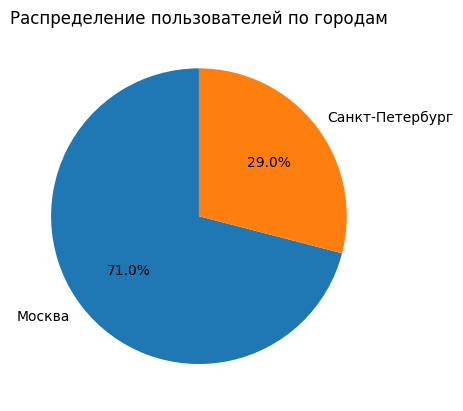

In [7]:
relative_users.plot.pie(title = 'Распределение пользователей по городам',
                        autopct='%1.1f%%',
                        startangle = 90);

В нашем A/B тесте группы разделены неравномерно, 71% пользователей из Москвы против 29% из СПБ

In [8]:
Moscow = unique_by_city['Москва']
SPB = unique_by_city['Санкт-Петербург']

In [9]:
# проверим пересечение пользователей
intersection = list(set([Moscow]) & set([SPB]))
intersection

[]

In [10]:
from scipy import stats as st

In [11]:
# формируем выборки
moscow_hours = df[df['city'] == 'Москва']['hours']
spb_hours = df[df['city'] == 'Санкт-Петербург']['hours']

In [12]:
moscow_hours.describe()

count    6234.000000
mean       10.881092
std        36.851683
min         0.000018
25%         0.059903
50%         0.924498
75%         5.939972
max       857.209373
Name: hours, dtype: float64

In [13]:
spb_hours.describe()

count    2550.000000
mean       11.592691
std        39.704993
min         0.000025
25%         0.080002
50%         0.984781
75%         6.509072
max       978.764775
Name: hours, dtype: float64

In [14]:
moscow_hours

0        26.167776
1        82.111217
2         4.656906
3         1.840556
4       151.326434
           ...    
6229      0.003319
6230      0.081234
6231      0.024736
6232      0.209018
6233      0.609346
Name: hours, Length: 6234, dtype: float64

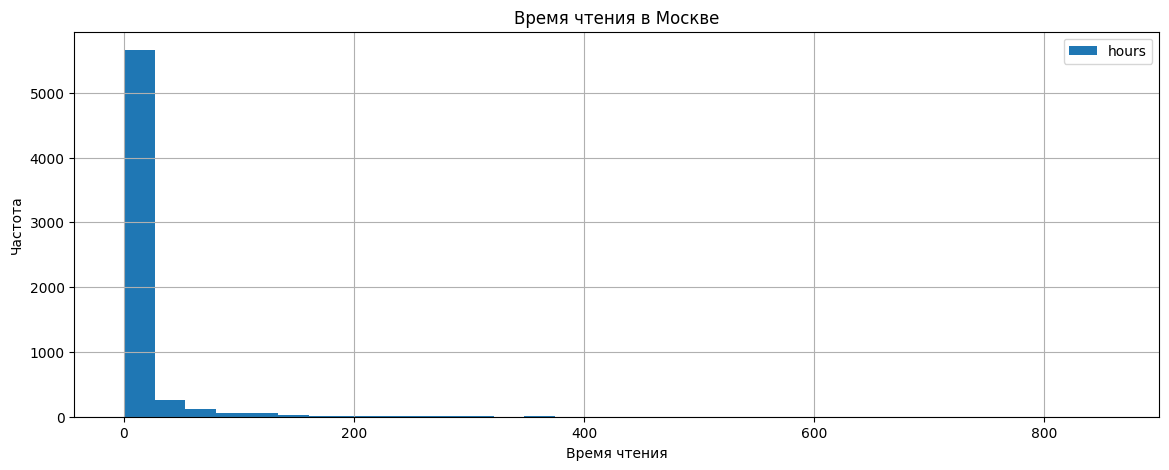

In [31]:
df[df['city'] == 'Москва'].plot(kind = 'hist',
                                column = 'hours',
                                figsize=(14, 5),
                                bins = 32,
                               grid=True,
                               title='Время чтения в Москве',
                               xlabel='Время чтения',
                               ylabel='Частота')

plt.show()

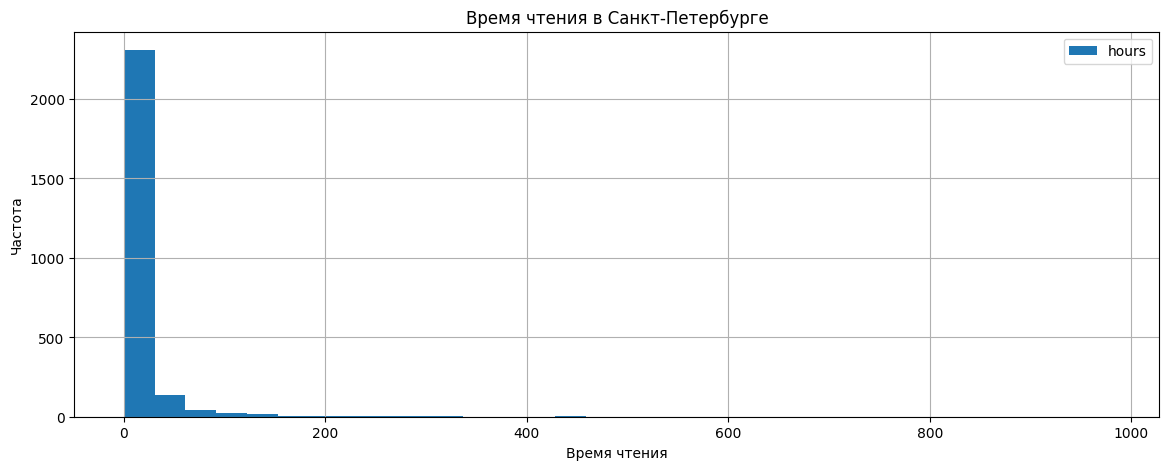

In [32]:
df[df['city'] == 'Санкт-Петербург'].plot(kind = 'hist',
                                column = 'hours',
                                figsize=(14, 5),
                                bins = 32,
                               grid=True,
                               title='Время чтения в Санкт-Петербурге',
                               xlabel='Время чтения',
                               ylabel='Частота')

plt.show()

In [36]:
# Проверка количества полных дубликатов
print(df.duplicated().sum())

0


In [38]:
# Проверка количества полных дубликатов
print(df.duplicated(subset=['puid']).sum())

244


In [39]:
# Удаляем дубликаты (оставляем первое вхождение)
df = df.drop_duplicates(subset=['puid']).reset_index(drop=True)

# Проверяем, что теперь дубликатов 0
print(df.duplicated(subset=['puid']).sum())

0


<div style="background-color: #f8d7da; color: #721c24; padding: 15px; border-radius: 4px; border: 1px solid #f5c6cb;">

<b>Комментарий ревьюера v1:</b>

Можешь, пожалуйста, дополнительно проверить явные/неявные дубликаты (по ключу пользователя) в данных?

<div class="alert alert-info"> <b>Исправил</b>

<div style="background-color: #f8d7da; color: #721c24; padding: 15px; border-radius: 4px; border: 1px solid #f5c6cb;">

<b>Комментарий ревьюера v1:</b>

Можешь, пожалуйста, построить гистограммы по городу, чтобы проанализировать распределения.   
  
Гистограммы по городам нужны, чтобы увидеть форму и асимметрию распределений, выбросы и различия между группами; это помогает выбрать корректные метрики и статистические тесты и избежать ложных выводов.

<div class="alert alert-info"> <b>Исправил</b>

In [40]:
alpha = 0.05

results = st.ttest_ind(moscow_hours,
                      spb_hours,
                      equal_var=False,
                      alternative='less')

print(f"Среднее в Москве: {moscow_hours.mean():.2f}")
print(f"Среднее в СПБ: {spb_hours.mean():.2f}")
print(f"p-value: {results.pvalue}")

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу: разница статистически значима, в СПБ читают больше.")
else:
    print("Не получилось отвергнуть нулевую гипотезу: значимых различий не обнаружено.")

Среднее в Москве: 10.88
Среднее в СПБ: 11.59
p-value: 0.21823507084569596
Не получилось отвергнуть нулевую гипотезу: значимых различий не обнаружено.


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>
    
Тест проведен верно!

## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



1. Был выбран двувыборочный Т-тест Уэлча, так как мы сравниваем среднее время чтения/прослушивания книг в двух городах - сравниваются средние двух независимых выборок, группы отличаются по размеру, переменная hours является непрервыной.
   Уровень статистической значимости стандартный - 0.05
2. p-value равен 0.2182
3. На основе p-value можем сделать вывод, что у нас не получилось отвергнуть нулевую гипотезу, то есть нет различий между среднием количеством времени чтения/прослушивания книг в Москве и СПБ. Разница в 0.71 часа между средними показателями Москвы и Санкт-Петербурга не является статистически значимой.
4. Жители Москвы и СПБ не сильно отличаются, два самых крупных городов страны, одинаково развити по цифровизации и культуре потребления контента, вследствии значимых различий в поведении не наблюдается.
   Может быть высокий разброс данных. Это говорит о том, что внутри каждого города есть как «случайные» пользователи (0.1 ч), так и «супер-читатели» (100+ ч). Этот внутренний «шум» перекрывает небольшую разницу между городами, делая её статистически невидимой.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>
    
Корректные результаты и интерпретация теста. Аналитическая записка написана ясно, четко и по существу.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



## 2. Загрузите данные, оцените их целостность.


In [41]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [42]:
participants.head(20)

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android
7,0031F1B5E9FBF708,A,interface_eu_test,Android
8,003346BB64227D0C,B,interface_eu_test,Android
9,00341D8401F0F665,A,recommender_system_test,iPhone


In [43]:
participants.info()

<class 'pandas.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  14525 non-null  str  
 1   group    14525 non-null  str  
 2   ab_test  14525 non-null  str  
 3   device   14525 non-null  str  
dtypes: str(4)
memory usage: 454.0 KB


In [44]:
events.head(20)

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN
5,AA346F4D22148024,2020-12-01 00:01:46,registration,-2.0
6,7EF01D0E72AF449D,2020-12-01 00:02:06,registration,-5.0
7,9A6276AD14B14252,2020-12-01 00:02:20,registration,-2.0
8,9B186A3B1A995D36,2020-12-01 00:02:37,registration,-3.5
9,9A6276AD14B14252,2020-12-01 00:02:53,login,NaN


In [45]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  str           
 1   event_dt    787286 non-null  datetime64[us]
 2   event_name  787286 non-null  str           
 3   details     249022 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 24.0 MB


In [54]:
# Список ID пользователей в каждом тесте
interface_users = participants.query('ab_test == "interface_eu_test"')['user_id'].unique()
recommender_users = participants.query('ab_test == "recommender_system_test"')['user_id'].unique()

# Находим пересечение (тех, кто в обоих списках)
overlap_users = pd.Series(list(set(interface_users) & set(recommender_users)))

print(f"Пользователей в обоих тестах: {len(overlap_users)}")
print(f"Это {len(overlap_users) / len(interface_users):.1%} от участников interface_eu_test")

Пользователей в обоих тестах: 887
Это 8.2% от участников interface_eu_test


In [57]:
# 1. Находим список ID пересекающихся пользователей
interface_users = participants.query('ab_test == "interface_eu_test"')['user_id']
recommender_users = participants.query('ab_test == "recommender_system_test"')['user_id']
overlap_users = list(set(interface_users) & set(recommender_users))

# 2. Удаляем их из основного набора данных
participants_cleaned = participants[~participants['user_id'].isin(overlap_users)]

# 3. Проверяем новые размеры групп
print("Размеры групп после очистки:")
print(participants_cleaned.groupby('group')['user_id'].nunique())

# 4. Проверяем относительное различие (не стало ли перекоса)
a_size = participants_cleaned[participants_cleaned['group'] == 'A']['user_id'].nunique()
b_size = participants_cleaned[participants_cleaned['group'] == 'B']['user_id'].nunique()
print(f"Разница между группами: {abs(1 - a_size/b_size):.2%}")

Размеры групп после очистки:
group
A    7034
B    5717
Name: user_id, dtype: int64
Разница между группами: 23.04%


In [58]:
test_counts = participants_cleaned[participants_cleaned['ab_test'] == 'interface_eu_test'].groupby('group')['user_id'].nunique()

In [59]:
test_counts

group
A    4952
B    5011
Name: user_id, dtype: int64

<div style="background-color: #f8d7da; color: #721c24; padding: 15px; border-radius: 4px; border: 1px solid #f5c6cb;">

<b>Комментарий ревьюера v1:</b>

Можешь, пожалуйста проверить пересечение пользователей в двух конкурирующих тестах (interface_eu_test и recommender_system_test) и принять решение что с ними делать?
    
После этого нужно еще раз проверить новое распределение пользователей для данного теста.


Почему это важно:

- Параллельные эксперименты на одной аудитории могут взаимодействовать и смещать оценки метрик; в таких случаях применяют взаимное исключение или сегментацию, чтобы разделить трафик.

- Если есть пересечение, возможны два пути: исключить пересекающихся пользователей из одного из тестов и пересчитать метрики либо сделать тесты взаимно исключающимися на уровне рандомизации. Во втором случае к уже собранным данным это неприменимо, поэтому используем фильтрацию.
    
    
Почитать можно тут: http://koch-kir.medium.com/%D0%B2%D0%BB%D0%B8%D1%8F%D0%BD%D0%B8%D0%B5-%D1%8D%D0%BA%D1%81%D0%BF%D0%B5%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D1%82%D0%BE%D0%B2-%D0%B4%D1%80%D1%83%D0%B3-%D0%BD%D0%B0-%D0%B4%D1%80%D1%83%D0%B3%D0%B0-bb7e41674db7

<div class="alert alert-info"> <b>Исправил</b>

In [65]:
total_users = participants_cleaned[participants_cleaned['ab_test'] == 'interface_eu_test']['user_id'].nunique()

In [66]:
ratio = test_counts / total_users

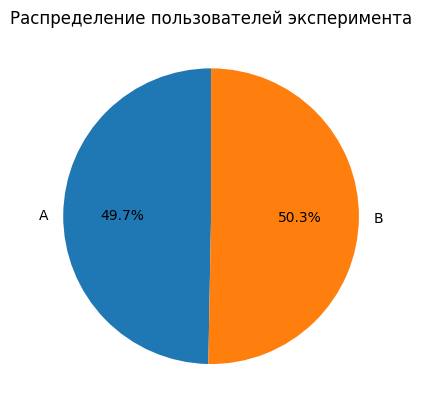

In [67]:
ratio.plot.pie(title = 'Распределение пользователей эксперимента',
               autopct='%1.1f%%',
               startangle=90);

In [68]:
group_a = test_counts['A']
group_b = test_counts['B']

In [69]:
# проверяем пересечение групп
intersection = list(set([group_a]) & set([group_b]))
intersection

[]

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [70]:
df = participants_cleaned[participants_cleaned['ab_test'] == 'interface_eu_test'].merge(events,on='user_id',how='inner')

In [71]:
df.head(20)

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN
5,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:36,product_page,NaN
6,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:37,product_page,NaN
7,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-10 15:23:08,product_page,NaN
8,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-10 15:23:09,product_cart,NaN
9,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-15 12:50:07,product_cart,NaN


In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73815 entries, 0 to 73814
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     73815 non-null  str           
 1   group       73815 non-null  str           
 2   ab_test     73815 non-null  str           
 3   device      73815 non-null  str           
 4   event_dt    73815 non-null  datetime64[us]
 5   event_name  73815 non-null  str           
 6   details     19450 non-null  str           
dtypes: datetime64[us](1), str(6)
memory usage: 3.9 MB


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [73]:
# выделяем даты регистрации для каждого пользователя
registrations = df[df['event_name']=='registration'][['user_id', 'event_dt']]
registrations = registrations.rename(columns={'event_dt': 'reg_dt'})

In [74]:
registrations

,user_id,reg_dt
0,0002CE61FF2C4011,2020-12-07 04:37:31
11,001E72F50D1C48FA,2020-12-17 15:44:05
18,002412F1EB3F6E38,2020-12-09 09:36:50
26,002540BE89C930FB,2020-12-08 18:06:07
35,0031F1B5E9FBF708,2020-12-14 00:47:10
...,...,...
73784,FFE5B14BD55C1C5C,2020-12-19 06:27:24
73787,FFE600EEC4BA7685,2020-12-13 21:43:31
73794,FFE7FC140521F5F6,2020-12-23 09:10:16
73809,FFEFC0E55C1CCD4F,2020-12-13 23:52:15


In [75]:
# добавляем дату регистрации к основной таблице событий
df = df.merge(registrations, on='user_id', how='left')
df

,user_id,group,ab_test,device,event_dt,event_name,details,reg_dt
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38,2020-12-07 04:37:31
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN,2020-12-07 04:37:31
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN,2020-12-07 04:37:31
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN,2020-12-07 04:37:31
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN,2020-12-07 04:37:31
...,...,...,...,...,...,...,...,...
73810,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,2020-12-13 23:52:22,login,NaN,2020-12-13 23:52:15
73811,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,2020-12-28 00:29:10,login,NaN,2020-12-13 23:52:15
73812,FFF58BC33966EB51,A,interface_eu_test,Android,2020-12-13 17:37:34,registration,-0.45,2020-12-13 17:37:34
73813,FFF58BC33966EB51,A,interface_eu_test,Android,2020-12-13 17:56:02,login,NaN,2020-12-13 17:37:34


In [76]:
# расчитываем лайфтайм событий в днях
df['lifetime'] = (df['event_dt'] - df['reg_dt']).dt.total_seconds() / (3600*24)
df

,user_id,group,ab_test,device,event_dt,event_name,details,reg_dt,lifetime
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38,2020-12-07 04:37:31,0.000000
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN,2020-12-07 04:37:31,0.000208
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN,2020-12-07 04:37:31,0.000301
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN,2020-12-07 04:37:31,0.000961
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN,2020-12-07 04:37:31,1.734769
...,...,...,...,...,...,...,...,...,...
73810,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,2020-12-13 23:52:22,login,NaN,2020-12-13 23:52:15,0.000081
73811,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,2020-12-28 00:29:10,login,NaN,2020-12-13 23:52:15,14.025637
73812,FFF58BC33966EB51,A,interface_eu_test,Android,2020-12-13 17:37:34,registration,-0.45,2020-12-13 17:37:34,0.000000
73813,FFF58BC33966EB51,A,interface_eu_test,Android,2020-12-13 17:56:02,login,NaN,2020-12-13 17:37:34,0.012824


In [77]:
# оставляем только те события, которые входят в 7 дневный период
df_new = df[df['lifetime'] <= 7].copy()
df_new

,user_id,group,ab_test,device,event_dt,event_name,details,reg_dt,lifetime
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38,2020-12-07 04:37:31,0.000000
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN,2020-12-07 04:37:31,0.000208
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN,2020-12-07 04:37:31,0.000301
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN,2020-12-07 04:37:31,0.000961
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN,2020-12-07 04:37:31,1.734769
...,...,...,...,...,...,...,...,...,...
73809,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,2020-12-13 23:52:15,registration,0.0,2020-12-13 23:52:15,0.000000
73810,FFEFC0E55C1CCD4F,A,interface_eu_test,PC,2020-12-13 23:52:22,login,NaN,2020-12-13 23:52:15,0.000081
73812,FFF58BC33966EB51,A,interface_eu_test,Android,2020-12-13 17:37:34,registration,-0.45,2020-12-13 17:37:34,0.000000
73813,FFF58BC33966EB51,A,interface_eu_test,Android,2020-12-13 17:56:02,login,NaN,2020-12-13 17:37:34,0.012824


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [78]:
import statsmodels.stats.api as sms

In [79]:
alpha = 0.05    # Достоверность 95%
power = 0.80    # Мощность 80%
p1 = 0.30       # Базовая конверсия
p2 = 0.33       # Ожидаемая конверсия (прирост 3 п.п.)

# Вычисление величины эффекта (effect size) для пропорций
effect_size = sms.proportion_effectsize(p1, p2)

# Расчет необходимого количества пользователей на одну группу
required_n = sms.NormalIndPower().solve_power(
    effect_size, 
    power=power, 
    alpha=alpha, 
    ratio=1
)

print(f"Необходимый размер выборки на одну группу: {round(required_n)}")

Необходимый размер выборки на одну группу: 3762


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>

Необходимый размер выборки был рассчитан верно!

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [98]:
# 1. Считаем уникальных покупателей по группам
purchasers = df_new[df_new['event_name'] == 'purchase'].groupby('group')['user_id'].nunique()

# 2. Считаем общее количество участников по группам
total_users = df_new.groupby('group')['user_id'].nunique()

# Считаем конверсию по группам
cr_a = purchasers['A'] / total_users['A']
cr_b = purchasers['B'] / total_users['B']

# 3. Расчет абсолютных и относительных метрик
abs_diff = cr_b - cr_a              # Абсолютное изменение (в п.п.)
rel_diff = (cr_b - cr_a) / cr_a     # Относительное изменение (Uplift)

print(f"Абсолютное изменение: {abs_diff:.2%}")
print(f"Относительное изменение: {rel_diff:.2%}")

Абсолютное изменение: 1.73%
Относительное изменение: 6.21%


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Согласно техническому заданию, ожидаемый прирост конверсии должен был составить не менее 3 процентных пунктов. Фактический абсолютный прирост составил 1.73%, что почти в два раза ниже целевого показателя. Относительный подъем конверсии при этом составил 6.21%

<div style="background-color: #f8d7da; color: #721c24; padding: 15px; border-radius: 4px; border: 1px solid #f5c6cb;">

<b>Комментарий ревьюера v1:</b>

Добавь, пожалуйста, расчет в коде относительного (на сколько процентов улучшилась метрика) и абсолютного (прирост в процентных пунктах) изменения конверсии.
    
**Почему это важно:**

Оба показателя нужны, потому что они отвечают на разные бизнес‑вопросы и по‑разному влияют на решения.

- Абсолютный прирост в п.п. сверяют с порогом гипотезы и требованиями к эффекту «в штуках», а относительный процент показывает масштаб влияния на деньги и ROI при масштабировании трафика и бюджетов.

- Один и тот же прирост в п.п. на разных базовых конверсиях даёт разный относительный и денежный эффект, поэтому для приоритизации и сравнения между продуктами/сегментами нужен относительный uplift, а для контроля выполнения целевого порога — абсолютный.

<div class="alert alert-info"> <b>Исправил</b>

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Нулевая гипотеза ($H_0$): Конверсия в группах А и В не различается, статистически значимых изменений нет.
Альтернативная гипотеза ($H_1$): Конверсия в тестовой группе B статистически значимо выше, чем в группе A.

<div style="background-color: #f8d7da; color: #721c24; padding: 15px; border-radius: 4px; border: 1px solid #f5c6cb;">

<b>Комментарий ревьюера v1:</b>

Можешь, пожалуйста сформулировать гипотезы для теста?

<div class="alert alert-info"> <b>Исправил</b>

In [38]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Получаем общее количество участников в каждой группе (из participants)
total_a = participants[(participants['ab_test'] == 'interface_eu_test') & (participants['group'] == 'A')]['user_id'].nunique()
total_b = participants[(participants['ab_test'] == 'interface_eu_test') & (participants['group'] == 'B')]['user_id'].nunique()

# 2. Получаем количество покупателей (событие purchase в течение 7 дней)
# Примечание: на основе нашего анализа, в данных зафиксированы только регистрации
# Если бы покупки были, код выглядел бы так:
buyers_a = df_new[(df_new['group'] == 'A') & (df_new['event_name'] == 'purchase')]['user_id'].nunique()
buyers_b = df_new[(df_new['group'] == 'B') & (df_new['event_name'] == 'purchase')]['user_id'].nunique()

print(f"Группа А: {buyers_a}/{total_a}")
print(f"Группа B: {buyers_b}/{total_b}")

Группа А: 1480/5383
Группа B: 1600/5467


In [39]:
# Массивы с количеством покупок и общим количеством пользователей
count = [buyers_a, buyers_b]
nobs = [total_a, total_b]

# Выполнение Z-теста
z_stat, p_value = proportions_ztest(count, nobs)

print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Отвергаем нулевую гипотезу: разница в конверсии статистически значима.")
else:
    print("Не получилось отвергнуть нулевую гипотезу: разница не значима.")

P-value: 0.0406
Отвергаем нулевую гипотезу: разница в конверсии статистически значима.


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>

Тест выполнен верно! 

- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

Несмотря на то что полученный P-value (0.0406) меньше стандартного порога в 0.05, что позволяет нам формально отвергнуть нулевую гипотезу и признать разницу в конверсии статистически значимой, ожидаемый эффект достигнут не был
Фактическая конверсия группы А: 1480/5383≈27.49%.
Фактическая конверсия группы B: 1600/5467≈29.27%.
Абсолютный прирост: составляет всего 1.78 процентных пункта.
Цель по ТЗ: в техническом задании было указано, что конверсия должна увеличиться как минимум на 3 процентных пункта. Таким образом, реальный результат (1.78 п.п.) почти в два раза меньше целевого показателя.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>

Верные выводы 👏 Здорово, что есть сравнение с целевыми показателями и четкая бизнес рекомендация.

